# E-Commerce Agentic Bots
1. 📦 Global Products Agent
- `Tools:` Web Scrapes from popular webpages such as Amazon, Spotify in `json-like format`
- `Description:` Writes a description about each product as well as their price, adhers to a specific pydantic format
- `PDF:` Saves Description about each item in a single PDF report, that can be vectorised and stored in a `vector database`

2. 🐼Chinese Latest Trend Agent
- `Tools:` API tools that fetches in `json-like format` or use `Tarvily` for web search smartly, an optimisted web-search library for LLM
- `Description:` Writes a summary about the latest news in china regarding products, general trends
- `PDF:` Saves the summary in a single PDF report, that can be vectorised and stored in a `vector database`

3. 🏛️📜Chinese Legal Platform, Commerical, Legal laws Agent
- `Tools:` uses `Tarvily` for web search smartly
- `Description:` Saves all these legal laws in a single document without reading them
- `PDF:` Saves all legal information in a single PDF report, that can be vectorised and stored in a `vector database`

4. ⛩️Chinese Cultural Nuance Creator Agent
- `Tools:` Access all PDF reports using `RAG` to generate a general report for chinese audience
- `PDF:` Saves a PDF report, that can be vectorised and stored in a `vector database`

5. 🎥Platform Specific Agent
- `Tools:` Access PDF generated by `Chinese Cultural Nuance Creator Agent` using `RAG` technique
- `Generation:` Generates a script for each specific platform separately

6. 🏮Translator Agent
- `Tools:` Access PDF generated by  Platform Specific Agent, translates it into several chinese dialects including Mandarin

# Product Agent
1. Webpages to scrape `http://books.toscrape.com/`
2. Made up of 3 Nodes (Web Scrapping)
    - Node A (Fetch and Minimise) given a webpage to be scrapped, it will scrape it and using soap to remove header, ads,  style, script, etc.. then convert it to `MarkDown` format instead of `html` , `MarkDown` is recommended format of data to be fed to agent
    - Node B (Extract) feeding output from Node A to Node B to and ask it to adhere to defined Product Schema
    - Node C (The Router/Validator) loops back to Node A if it did not successfully fetch data
3. Records How many calls, time taken to finish the task, also things that slowed down agent while working
4. API to be called `https://api.escuelajs.co/api/v1/products`
5. Made up of 2 Nodes (API)
    - Node A (Fetch and Match) given API json data, some of titles might not match with data, agent job is to make it match with current schema
    - Node B (The Router/Validator) loops back to Node A if it did not successfully fetch data
6. Records How many calls, time taken to finish the task, also things that slowed down agent while working

    

In [1]:
WEB_PAGES_SCRAPE=["https://api.escuelajs.co/api/v1/products","http://books.toscrape.com/"]

In [83]:
from pydantic import BaseModel, Field
from typing import List, Literal, Optional
from typing_extensions import Annotated, TypedDict
from langgraph.graph.message import add_messages

class Product(BaseModel):
    name: str
    price: float
    description: str
    category: str | None = Field(description="name of the category the product belongs to")
    rating: float | None = Field(description="extract the rating of the product if it only exists, do not make it up")
    source_url : str = Field(description="write URL of this product in full , which webpage was it extracted from, acquire that from URLSchema.web_scrape_url or URLSchema.api_url")

class ProductCatalog(BaseModel):
    products : List[Product] = Field(description="A list of e-commerce products")

class URLSchema(BaseModel):
    web_scrape_url: str | None = Field(description="only url thats doesn't contain word api in them, assume they are to web scrape url, write that url here only",
                                examples=["http://example.com"])
    api_url: str | None = Field(description="Urls that contain api term in them assume write that url here only",
                         examples=["https://api.postman.com"])

class AnalysisSchema(BaseModel):
    pass

def merge_products(current: List[Product], new: List[Product]) -> List[Product]:
    print("current :",current)
    print("new : ",new)
    if not current:
        print("returning only new!")
        return new
    merged_list = current + new
    return merged_list
    


class State(TypedDict):
    messages: Annotated[list[str], add_messages]
    messages_web_scrape: str | None
    messages_api: str | None
    products_list: Annotated[list[Product], merge_products]
    number_of_sources_extracted: int = 0
    target_retry_node: Optional[str]
    error_messages : Annotated[list[str], add_messages]

# Scrapping + API Sub-Graph

In [84]:
from langchain.chat_models import init_chat_model

product_llm = init_chat_model(model="gemini-3.1-flash-lite", model_provider="google_genai")

In [ ]:
from requests import request
from bs4 import BeautifulSoup
from html_to_markdown import convert
import time

def fetch_raw_html(state: State):
    """Given URL it web scrapes to get html, this html is cleaned and unwanted tags are removed"""
    print("state is",state["messages"])
    last_message = state["messages"][-1].content
    extract_url_llm = product_llm.with_structured_output(URLSchema)
    results = extract_url_llm.invoke([{
        "role":"system","content":"Get string of URL only",
        "role":"user","content":last_message
    }])
    url = results.web_scrape_url
    print("url is",url)
    # url="http://books.toscrape.com/"
    if url is None:
        return
    exclude_tags=["script","head","title","style","svg","!doctype","meta"]
    try:
        time.sleep(0.5)
        response = request(method="GET",url=url)
        if response.status_code == 200:
            soup =  BeautifulSoup(response.text, "html.parser")

            for tag in exclude_tags:
                for match in soup.find_all(tag):
                    match.extract()

            return {"messages_web_scrape":str(soup)}

        else:
            return f"Error Failed to fetch raw HTML from fetch_raw_html() Reason : Response_Code is  {response.status_code}"
    except Exception as e:
        return f"Error Failed to fetch raw HTML from fetch_raw_html() Reason : {e}"


def clean_to_markdown(state: State):
    """the cleaned html from fetch_raw_html() is then converted to markdown format"""
    html_content = state["messages_web_scrape"]
    markdown_object = convert(str(html_content))
    markdown = markdown_object.content
    return {"messages_web_scrape":markdown}

def extract_structured_data(state: State):
    """Given a markdown or json-like format as input, it is taken to extract products information according to pydantic Schema format"""
    markdown = state["messages_web_scrape"]
    api = state["messages_api"]

    if markdown is None:
        process_message = api
    else:
        process_message = markdown

    print("last message in extract_structured_data is",markdown)
    structured_output_llm = product_llm.with_structured_output(ProductCatalog)
    msg = [
        {"role":"system","content":"extract the text from markdown or json-like format and give output in pydantic specified format"},
        {"role":"user","content":process_message}
    ]
    product_cat_object = structured_output_llm.invoke(msg)

    if markdown is not None:
        state["messages_web_scrape"]=None

    if api is not None:
        state["messages_api"]=None

    # increment = state["number_of_sources_extracted"] + 1

    return {"products_list":product_cat_object.products}
    

def fetch_api_data(state: State):
    """Given URL use to fetch json-like data"""
    print("state is",state["messages"])
    last_message = state["messages"][-1].content
    extract_url_llm = product_llm.with_structured_output(URLSchema)
    results = extract_url_llm.invoke([{
        "role":"system","content":"Get string of URL only API URL",
        "role":"user","content":last_message
    }])
    url = results.api_url
    print("url is",url)
    # url="http://books.toscrape.com/"
    if url is None:
        return
    try:
        time.sleep(0.5)
        response = request(method="GET",url=url)
        print("fetch_api_data() response is",response.json())
        if response.status_code == 200:
            return {"messages_api":str(response.json())}

        else:
            return f"Error Failed to fetch raw HTML from fetch_api_data() Reason : Response_Code is  {response.status_code}"
    except Exception as e:
        return f"Error Failed to fetch raw HTML from fetch_api_data() Reason : {e}"



def validate_extraction(state: State):
    """Validate that extraction for each URL Article was successfully carried out, point out any missing information, feel free to start again
    at either fetch_raw_html() or fetch_api_data() or even extract_structured_data() depending on what went wrong, explain to me what went wrong
    and if there is rundant steps let me know what are they, also look for any duplications in data
    """
    products_list = state["products_list"][-1].content

    analysis_product_llm = product_llm.with_structured_output()
    message = analysis_product_llm.invoke([{
        "role":"system","content":"Explain what went wrong, and if there is any duplication in data",
        "role":"user","content":products_list
    }])

In [90]:
from langgraph.graph import StateGraph, START, END


graph = StateGraph(State)
graph.add_node("fetch_raw_html",fetch_raw_html)
graph.add_node("fetch_api_data",fetch_api_data)
graph.add_node("clean_to_markdown",clean_to_markdown)
graph.add_node("extract_structured_data",extract_structured_data)
graph.add_edge(START,"fetch_raw_html")
graph.add_edge(START,"fetch_api_data")
graph.add_edge("fetch_raw_html","clean_to_markdown")
graph.add_edge("fetch_api_data","extract_structured_data")
graph.add_edge("clean_to_markdown","extract_structured_data")
graph.add_edge("extract_structured_data",END)
compiled_graph = graph.compile()



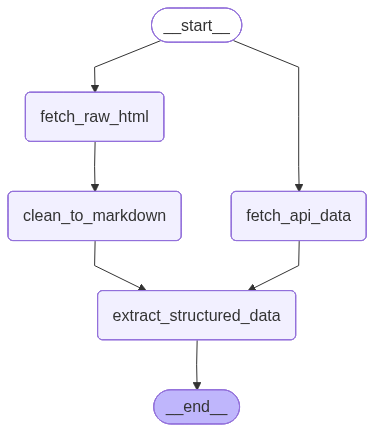

In [91]:
from IPython.display import Image

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

In [92]:
inputs = {
    "messages": [
        {
            "role": "user", 
            "content": "Use this url to extract at only 10 books http://books.toscrape.com/ and from the following api  get 10 products at least https://api.escuelajs.co/api/v1/products return both products a single list"
        }
    ]
}

compiled_graph.invoke(
inputs
)

state is [HumanMessage(content='Use this url to extract at only 10 books http://books.toscrape.com/ and from the following api  get 10 products at least https://api.escuelajs.co/api/v1/products return both products a single list', additional_kwargs={}, response_metadata={}, id='dbb2c6b4-a644-4507-a0e5-5687ed35477a')]
state is [HumanMessage(content='Use this url to extract at only 10 books http://books.toscrape.com/ and from the following api  get 10 products at least https://api.escuelajs.co/api/v1/products return both products a single list', additional_kwargs={}, response_metadata={}, id='dbb2c6b4-a644-4507-a0e5-5687ed35477a')]
url is https://api.escuelajs.co/api/v1/products
url is http://books.toscrape.com/
fetch_api_data() response is [{'id': 10, 'title': 'Classic Blue Baseball Cap', 'slug': 'classic-blue-baseball-cap', 'price': 86, 'description': 'Top off your casual look with our Classic Blue Baseball Cap, made from high-quality materials for lasting comfort. Featuring a timeless

{'messages': [HumanMessage(content='Use this url to extract at only 10 books http://books.toscrape.com/ and from the following api  get 10 products at least https://api.escuelajs.co/api/v1/products return both products a single list', additional_kwargs={}, response_metadata={}, id='dbb2c6b4-a644-4507-a0e5-5687ed35477a')],
 'messages_web_scrape': '[Books to Scrape](index.html) We love being scraped!\n\n- [Home](index.html)\n- All products\n\n# All products\n\n**Warning!** This is a demo website for web scraping purposes. Prices and ratings here were randomly assigned and have no real meaning.\n\n1.\n\n[![A Light in the Attic](media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg)](catalogue/a-light-in-the-attic_1000/index.html)\n\n  \n\n### [A Light in the ...](catalogue/a-light-in-the-attic_1000/index.html "A Light in the Attic")\n      Â£51.77\n\n     In stock\n\n2.\n\n[![Tipping the Velvet](media/cache/26/0c/260c6ae16bce31c8f8c95daddd9f4a1c.jpg)](catalogue/tipping-the-velvet_999/ind